In [ ]:
# Figure 1 

In [22]:

import netCDF4 as nc4
import numpy as np
import glob as glob
import matplotlib.pyplot as plt
from scipy import stats



import glob as glob
import os
from collections import OrderedDict
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as nc4
import matplotlib.pyplot as plt
import matplotlib as mpl
from pylab import *; 
import cartopy
import cartopy.crs as ccrs
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300





def pop_add_cyclic(ds): # pass an xarray object into this
    nj = ds.TLAT.shape[0] # size of POP grid
    ni = ds.TLONG.shape[1]
    xL = int(ni/2 - 1)
    xR = int(xL + ni)
    tlon = ds.TLONG.data
    tlat = ds.TLAT.data
    tlon = np.where(np.greater_equal(tlon, min(tlon[:,0])), tlon-360., tlon) #make monotoncially increasing
    lon  = np.concatenate((tlon, tlon + 360.), 1) # concatenate to make larger array
    lon = lon[:, xL:xR] #restrict to middle rane
    if ni == 320: # this is the x1 POP grid
        print('\n')
    lon = lon - 360.
    lon = np.hstack((lon, lon[:, 0:1] + 360.)) # add in cyclic point
    if ni == 320:
        print('\n')
    #-- periodicity
    lat = np.concatenate((tlat, tlat), 1)
    lat = lat[:, xL:xR]
    lat = np.hstack((lat, lat[:,0:1]))
    TLAT = xr.DataArray(lat, dims=('nlat', 'nlon'))
    TLONG = xr.DataArray(lon, dims=('nlat', 'nlon'))
    dso = xr.Dataset({'TLAT': TLAT, 'TLONG': TLONG})
    # copy vars
    varlist = [v for v in ds.data_vars if v not in ['TLAT', 'TLONG']]
    for v in varlist:
        v_dims = ds[v].dims
        if not ('nlat' in v_dims and 'nlon' in v_dims):
            dso[v] = ds[v]
        else:
            # determine and sort other dimensions
            other_dims = set(v_dims) - {'nlat', 'nlon'}
            other_dims = tuple([d for d in v_dims if d in other_dims])
            lon_dim = ds[v].dims.index('nlon')
            field = ds[v].data
            field = np.concatenate((field, field), lon_dim)
            field = field[..., :, xL:xR]
            field = np.concatenate((field, field[..., :, 0:1]), lon_dim)       
            dso[v] = xr.DataArray(field, dims=other_dims+('nlat', 'nlon'), 
                                  attrs=ds[v].attrs)
    # copy coords
    for v, da in ds.coords.items():
        if not ('nlat' in da.dims and 'nlon' in da.dims):
            dso = dso.assign_coords(**{v: da})     
    return dso


    
    

def get_colors(string,num,add_white = -1):
    #from pylab import *; 
    cmap = cm.get_cmap(string, num)    # PiYG
    colors=[]
    for i in range(cmap.N):
        rgb = cmap(i)[:3] # will return rgba, we take only first 3 so we get rgb
        colors.append(str(matplotlib.colors.rgb2hex(rgb))) 
    if add_white != -1:
        colors.insert(add_white,'#FFFFFF')
    return colors







from datetime import datetime, timedelta

def convert_days_to_date(days_since_origin, origin_date_str="0001-01-01"):
    """
    Converts a number of days since a specified origin date to an actual date.

    Args:
        days_since_origin (int or float): The number of days since the origin.
        origin_date_str (str): The origin date in 'YYYY-MM-DD' format.

    Returns:
        datetime.datetime: The calculated actual date and time.
    """
    # 1. Define the origin date as a datetime object
    origin_date = datetime.strptime(origin_date_str, "%Y-%m-%d")

    # 2. Create a timedelta object from the number of days
    delta = timedelta(days=days_since_origin)

    # 3. Add the timedelta to the origin date to get the resulting date
    actual_date = origin_date + delta

    return actual_date



def running_mean(data,n):
  data_n = [np.nan]*n; t = n
  while t in range(len(data)-n):
    data_n.append(np.nanmean(data[t-n:t+n+1]))
    t = t+1
  return data_n + [np.nan]*n






def running_mean(data,n):
  data_n = [np.nan]*n; t = n
  while t in range(len(data)-n):
    data_n.append(np.nanmean(data[t-n:t+n+1]))
    t = t+1
  return data_n + [np.nan]*n



def separate_by_month_arrays(dataset):
	k=0
	jan=[];feb=[];march=[];apr=[];may=[];jun=[];july=[];aug=[];sep=[];oc=[];nov=[];dec=[];
	while k <= (len(dataset)-12):
		jan.append((dataset[k]))
		feb.append((dataset[k+1]))
		march.append((dataset[k+2]))
		apr.append((dataset[k+3]))
		may.append((dataset[k+4]))
		jun.append((dataset[k+5]))
		july.append((dataset[k+6]))
		aug.append((dataset[k+7]))
		sep.append((dataset[k+8]))
		oc.append((dataset[k+9]))
		nov.append((dataset[k+10]))
		dec.append((dataset[k+11]))
		k = k+12;
	return [jan,feb,march,apr,may,jun,july,aug,sep,oc,nov,dec]

def monthly_anomaly(data,data_control,type='standard',NANDATA = False):
    monthly_data = separate_by_month_arrays(data)
    monthly_data_control = np.nanmean(separate_by_month_arrays(data_control),axis=1)
    new_data=[]
    if type == 'percent':
        return percent_anomaly(data,data_control)
    if type == 'standard':
        for yr in range(int(len(data)/12.0)):
            for mo in range(12):
                new_data.append(monthly_data[mo][yr] - monthly_data_control[mo])
        return new_data
    if type == 'sd':
        mdc_std = np.nanstd(separate_by_month_arrays(data_control),axis=1)
        for yr in range(int(len(data)/12.0)):
    	    for mo in range(12):
	          new_data.append( (monthly_data[mo][yr] - monthly_data_control[mo]) *(mdc_std[mo]**-1))
        return new_data

    
    



In [23]:
def compute_global_integral_phytoplankton(ds,var='photoC_TOT_zint'): # function only handles biomass
    z = ds[var]
    A = ds["TAREA"] * 1e-4   # cm² → m²
    A_masked = A.where(z.notnull())
    scale_factor=1e-3*12*1e-15*86400*365*1e-2
    global_int = (z * A_masked).sum(dim=("nlat", "nlon"))*scale_factor 
    return global_int.rename("global_sum_photoC_TOT_zint") # rename


In [36]:
#these_cases=['fosi_ur_150tg_01_alluv','nw_ip_5tg_tuv_ens01','nw_ip_46p8_tuv_ens01','nw_ur_150_tuv_01','nw_cntrl_tuv_01']
these_cases=['fosi_ur_150tg_01_alluv','fosi_ip_5tg_01_alluv','fosi_ip_46p8_01_alluv','fosi_ur_150tg_01_alluv','nw_cntrl_tuv_01']#these_cases=['fosi_ur_150tg_01_alluv','nw_ip_5tg_tuv_ens01','nw_ip_46p8_tuv_ens01','nw_ur_150_tuv_01','nw_cntrl_tuv_01']']
these_cases=['nw_ur_150_tuv_01','nw_ip_46p8_tuv_ens01','nw_ip_5tg_tuv_ens01','nw_cntrl_tuv_01']
data_directory = '/scratch/alpine/joco6825/cesm/nw_cases/archive/manuscript_data/'


VARIABLES=['photoC_TOT_zint','photoC_diat_zint','photoC_sp_zint','photoC_cocco_zint']


files={}
for case in these_cases:
    files[case]={}
    for VAR in VARIABLES:
        files[case][VAR]=sorted(glob.glob(data_directory+case+'/'+case+'.pop.h.'+VAR+'.*.nc'))

   
       
example_file=files[case][VAR][0]



In [37]:
monthly_data={}
for case in these_cases:
    monthly_data[case]={}

# globally integrated NPP
#extract = nc4.Dataset(example_file,'r')
#TAREA = extract.variables['TAREA'][:]*(100**-2)
#scale_factor=1e-3*12*1e-15*86400*365*1e-2

for case in these_cases:
    for current_var in ['photoC_TOT_zint','photoC_diat_zint','photoC_sp_zint','photoC_cocco_zint']:
        ds = xr.open_mfdataset(files[case][current_var],)
        monthly_data[case][current_var] = compute_global_integral_phytoplankton(ds,var=current_var)
        

In [38]:

for case in these_cases:
    for current_var in ['photoC_TOT_zint','photoC_diat_zint','photoC_sp_zint','photoC_cocco_zint']:
        ds = xr.open_mfdataset(files[case][current_var])
        monthly_data[case][current_var] = monthly_data[case][current_var].values
        

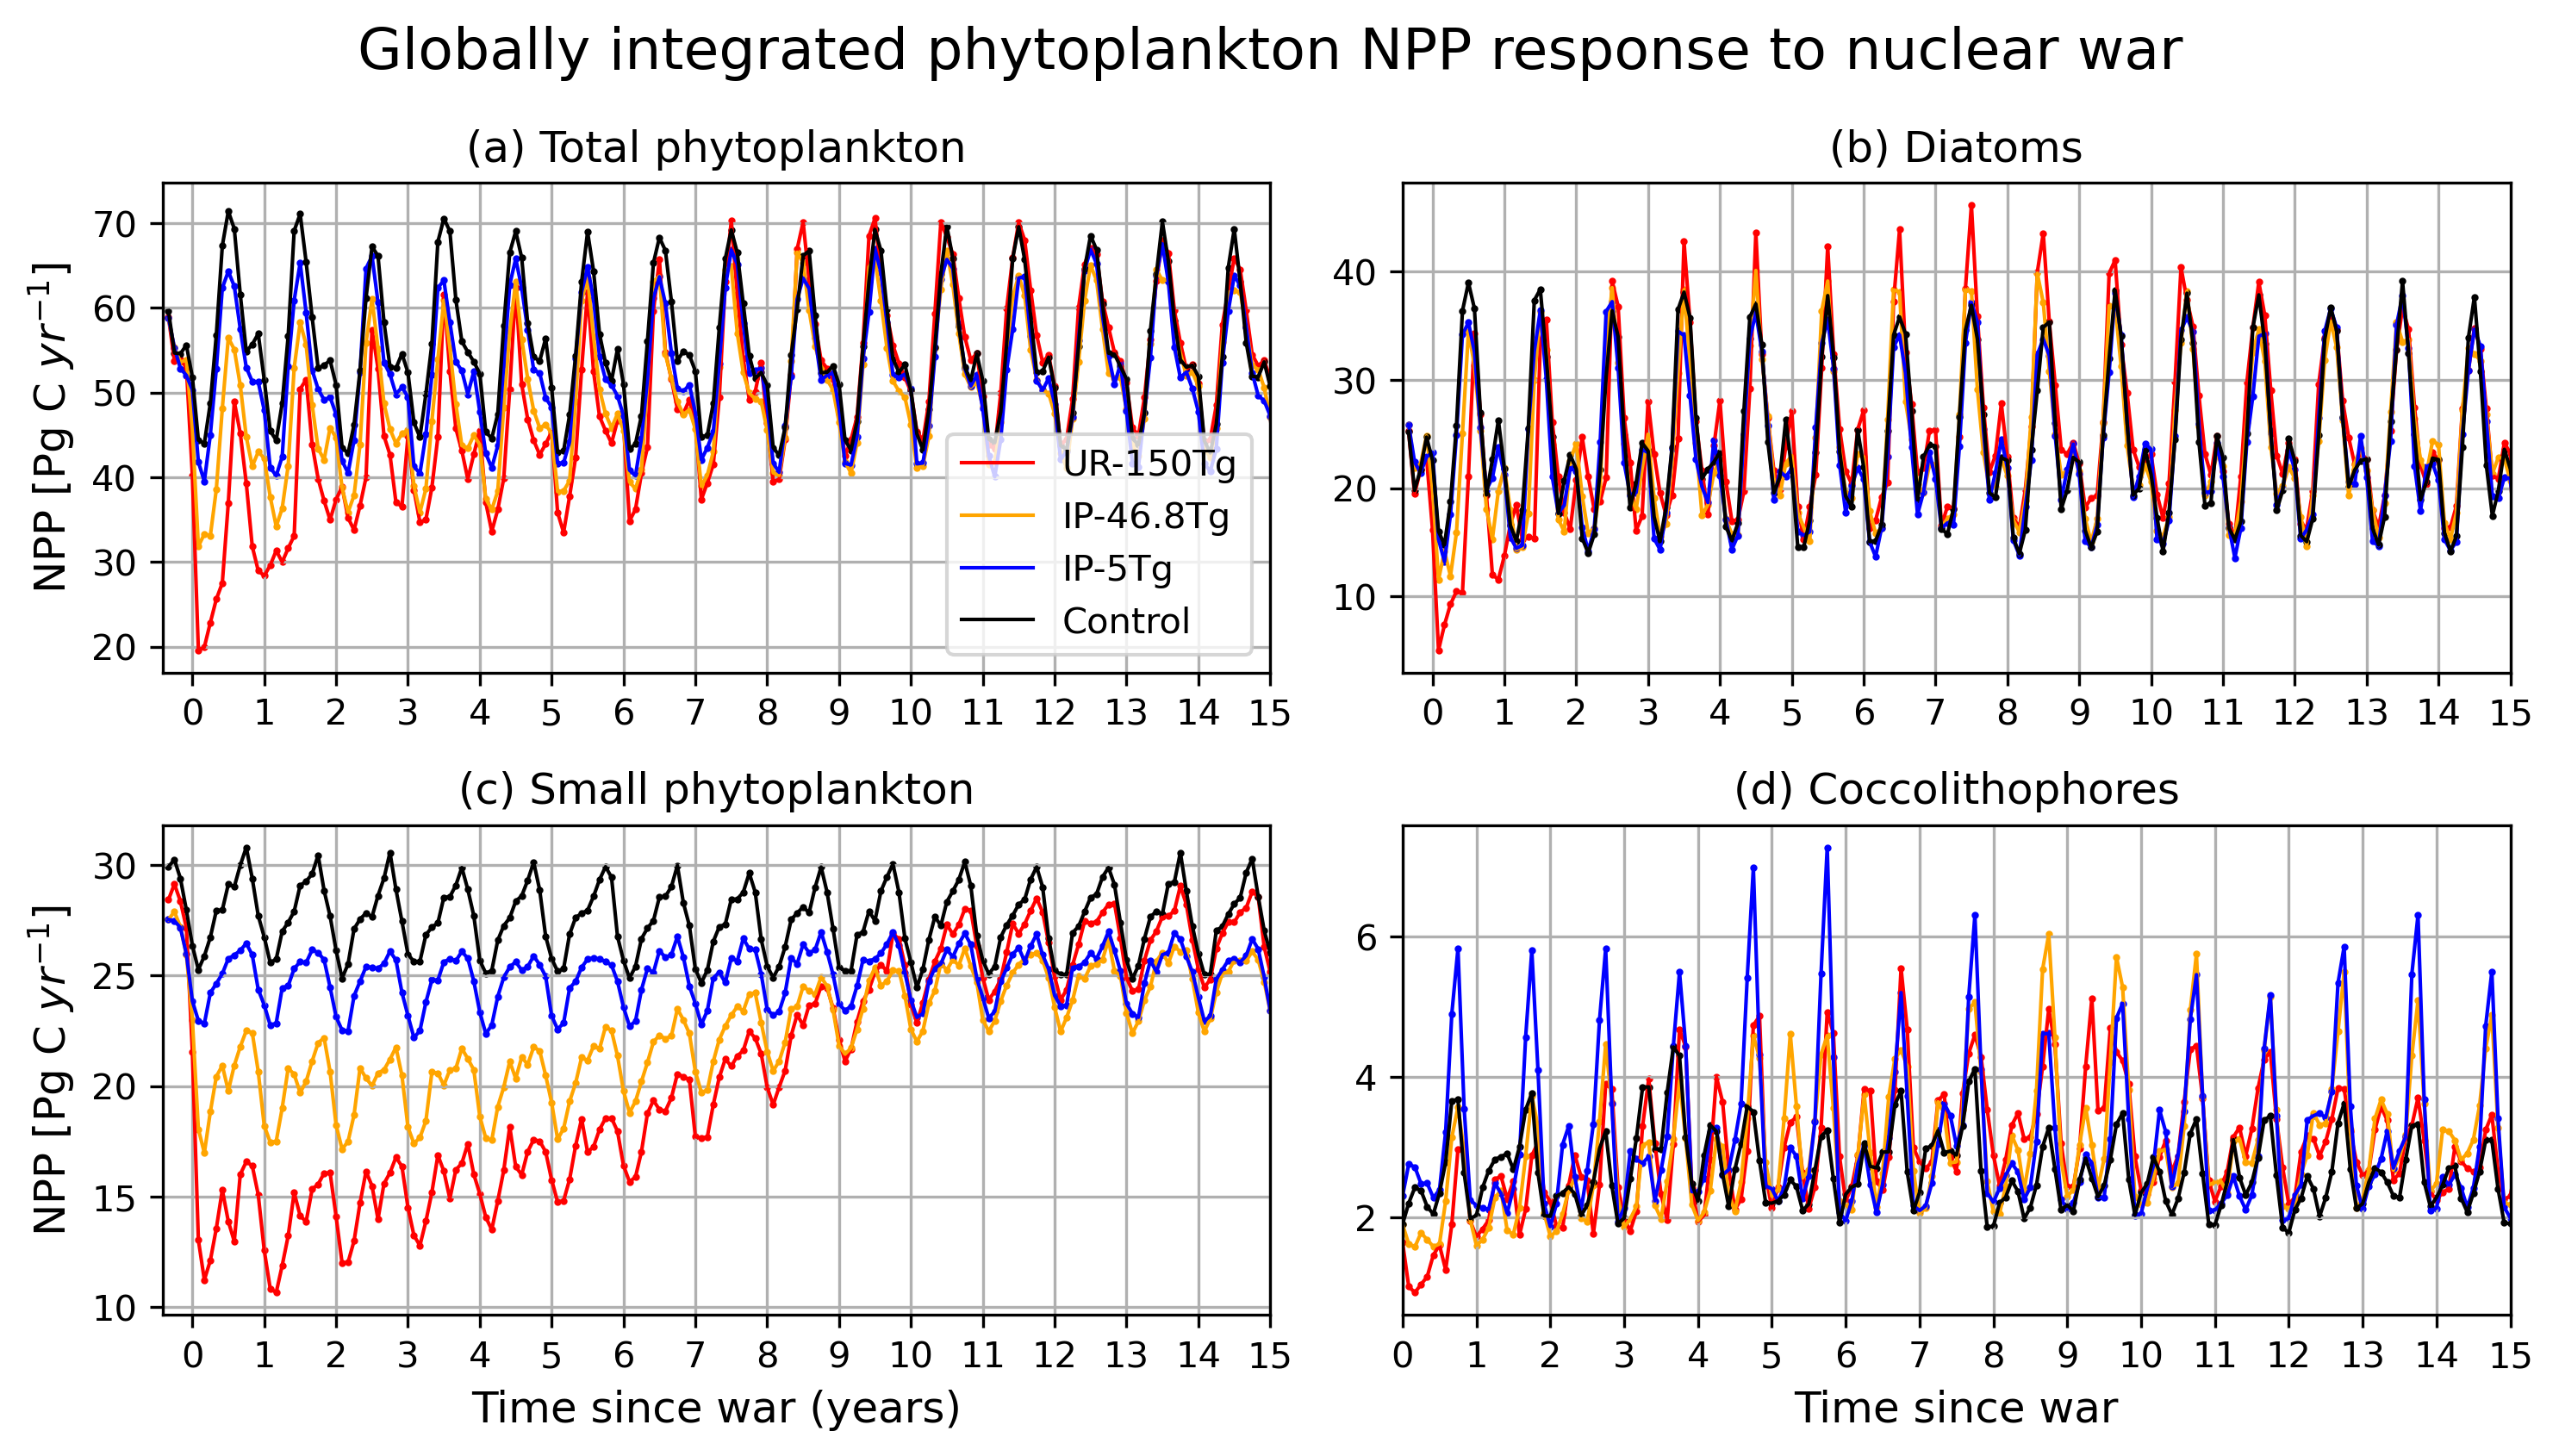

In [39]:
# Create plot

these_cases=['fosi_ip_5tg_01_alluv','fosi_ip_5tg_01_ctluv','nw_cntrl_tuv_01']
these_cases=['fosi_ur_150tg_01_alluv','fosi_ip_46p8_01_alluv','fosi_ip_5tg_01_alluv','nw_cntrl_tuv_01']
these_cases=['nw_ip_5tg_tuv_ens01','nw_ip_46p8_tuv_ens01','nw_ur_150_tuv_01','nw_cntrl_tuv_01']
these_cases=['nw_ur_150_tuv_01','nw_ip_46p8_tuv_ens01','nw_ip_5tg_tuv_ens01','nw_cntrl_tuv_01']
#these_cases=['fosi_ur_150tg_01_alluv','fosi_ip_46p8_01_alluv','fosi_ip_5tg_01_alluv','nw_cntrl_tuv_01'] # use datm run instead of fully coupled


CASE_LABELS={} # maintain full control over this 
CASE_LABELS['nw_ip_46p8_tuv_ens01']='India-Pakistan 46.8 Tg'
CASE_LABELS['nw_cntrl_tuv_01']='Control'
CASE_LABELS['fosi_ip_5tg_01_alluv']='5 Tg (perturbed UV)'
CASE_LABELS['fosi_ip_5tg_01_ctluv'] = '5 Tg (control UV)'
CASE_LABELS['fosi_ur_150tg_01_alluv'] = 'UR-150Tg'
CASE_LABELS['fosi_ip_46p8_01_alluv']='IP-46.8Tg'
CASE_LABELS['fosi_ip_5tg_01_alluv'] = 'IP-5Tg'

CASE_LABELS['nw_ip_5tg_tuv_ens01']='IP-5Tg'
CASE_LABELS['nw_ip_46p8_tuv_ens01'] = 'IP-46.8Tg'
CASE_LABELS['nw_ur_150_tuv_01']='UR-150Tg'
CASE_COLORS={}
CASE_COLORS['fosi_ip_46p8_01_alluv']='orange'
CASE_COLORS['nw_cntrl_tuv_01']='k'
CASE_COLORS['fosi_ur_150tg_01_alluv']='r'
CASE_COLORS['fosi_ip_46p8_01_alluv']='orange'
CASE_COLORS['fosi_ip_5tg_01_alluv']='blue'

CASE_COLORS['nw_ur_150_tuv_01']='r'
CASE_COLORS['nw_ip_46p8_tuv_ens01']='orange'
CASE_COLORS['nw_ip_5tg_tuv_ens01']='blue'
CASE_COLORS['nw_cntrl_tuv_01']='k' # monthly_data['nw_ur_150_tuv_01']['photoC_TOT_zint']

scatter_size=1
scale=1
offset=-5
FONTSIZE={}
FONTSIZE['SUPTITLE']=16
FONTSIZE['TITLE']=12
FONTSIZE['YLABEL']=12
FONTSIZE['XLABEL']=12
FONTSIZE['XTICKS']=10

XLIM_MAX = 12*15


fig = plt.figure(figsize=(10,5.7),facecolor='white')
gs = fig.add_gridspec(2, 2)
plt.suptitle('Globally integrated phytoplankton NPP response to nuclear war ',fontsize=FONTSIZE['SUPTITLE'])

#
# PHOTOC_TOT_ZINT
#
VAR='photoC_TOT_zint'
ax1=fig.add_subplot(gs[0,0],facecolor='white')#,projection=ccrs.Robinson(central_longitude=-60))
ax1.set_title('(a) Total phytoplankton',fontsize=FONTSIZE['TITLE']);
ax1.set_ylabel('NPP [Pg C $yr^{-1}$]',fontsize=FONTSIZE['YLABEL']); 
#ax1.set_xlabel('Time since impact (years)',fontsize=FONTSIZE['XLABEL'])
ax1.set_xticks(np.array([0,12,24,36,48,60,72,84,96,108,120,132,144,156,168,180,192,204,216,228]),\
               ('0','1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16','17','18','19'),fontsize=FONTSIZE['XTICKS'])


# option to cycle control to make plots more digestable
CYCLE_CONTROL=False; TOTAL_CYCLES=2; case='nw_cntrl_tuv_01'
if CYCLE_CONTROL:
    one_cycle = list(monthly_data[case][VAR])
    for cycle in range(TOTAL_CYCLES):
        monthly_data[case][VAR] = list(monthly_data[case][VAR]) + one_cycle


for case in these_cases:
    DATA= monthly_data[case][VAR]
    ts = np.linspace(0,len(DATA),len(DATA))
    ts=np.linspace(1,len(DATA[:]),len(DATA)) + offset; #print(len(ts))
    ax1.scatter(ts,DATA[:],c=CASE_COLORS[case],s=scatter_size)
    ax1.plot(ts,DATA,CASE_COLORS[case],label=CASE_LABELS[case],linewidth=1*scale); 

ax1.set_xlim([offset,XLIM_MAX])
#ax1.axhline(0,color='grey',linestyle='--')
ax1.grid(); 
ax1.legend(loc='best')

#
# photoC_diat_zint
#
VAR='photoC_diat_zint'
ax2=fig.add_subplot(gs[0,1],facecolor='white')#,projection=ccrs.Robinson(central_longitude=-60))
ax2.set_title('(b) Diatoms',fontsize=FONTSIZE['TITLE']);
#ax2.set_ylabel('NPP [Pg C $yr^{-1}$]',fontsize=FONTSIZE['YLABEL']); 
#ax2.set_xlabel('Time since impact (years)',fontsize=FONTSIZE['XLABEL'])
ax2.set_xticks(np.array([0,12,24,36,48,60,72,84,96,108,120,132,144,156,168,180,192,204,216,228]),\
               ('0','1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16','17','18','19'),fontsize=FONTSIZE['XTICKS'])



# option to cycle control to make plots more digestable
#CYCLE_CONTROL=True; TOTAL_CYCLES=2; 
case='nw_cntrl_tuv_01'
if CYCLE_CONTROL:
    one_cycle = list(monthly_data[case][VAR])
    for cycle in range(TOTAL_CYCLES):
        monthly_data[case][VAR] = list(monthly_data[case][VAR]) + one_cycle

        
for case in these_cases:
    DATA= monthly_data[case][VAR]
    ts = np.linspace(0,len(DATA),len(DATA))
    ts=np.linspace(1,len(DATA[:]),len(DATA)) + offset; #print(len(ts))
    ax2.scatter(ts,DATA[:],c=CASE_COLORS[case],s=scatter_size)
    ax2.plot(ts,DATA,CASE_COLORS[case],label=CASE_LABELS[case],linewidth=1*scale); 

ax2.set_xlim([offset,XLIM_MAX])
#ax2.axhline(0,color='grey',linestyle='--')
ax2.grid(); 
#ax2.legend(loc='best')

#
# photoC_sp_zint
#
VAR='photoC_sp_zint'
ax3=fig.add_subplot(gs[1,0],facecolor='white')#,projection=ccrs.Robinson(central_longitude=-60))
ax3.set_title('(c) Small phytoplankton',fontsize=FONTSIZE['TITLE']);
ax3.set_ylabel('NPP [Pg C $yr^{-1}$]',fontsize=FONTSIZE['YLABEL']); 
ax3.set_xlabel('Time since war (years)',fontsize=FONTSIZE['XLABEL'])
ax3.set_xticks(np.array([0,12,24,36,48,60,72,84,96,108,120,132,144,156,168,180,192,204,216,228]),\
               ('0','1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16','17','18','19'),fontsize=FONTSIZE['XTICKS'])

        

# option to cycle control to make plots more digestable
#CYCLE_CONTROL=True; TOTAL_CYCLES=2; 
case='nw_cntrl_tuv_01'
if CYCLE_CONTROL:
    one_cycle = list(monthly_data[case][VAR])
    for cycle in range(TOTAL_CYCLES):
        monthly_data[case][VAR] = list(monthly_data[case][VAR]) + one_cycle

        
for case in these_cases:
    DATA= monthly_data[case][VAR]
    ts = np.linspace(0,len(DATA),len(DATA))
    ts=np.linspace(1,len(DATA[:]),len(DATA)) + offset; #print(len(ts))
    ax3.scatter(ts,DATA[:],c=CASE_COLORS[case],s=scatter_size)
    ax3.plot(ts,DATA,CASE_COLORS[case],label=CASE_LABELS[case],linewidth=1*scale); 

ax3.set_xlim([offset,XLIM_MAX])
#ax3.axhline(0,color='grey',linestyle='--')
ax3.grid(); 
#ax3.legend(loc='best')


#
# photoC_cocco_zint
#
VAR='photoC_cocco_zint'
ax4=fig.add_subplot(gs[1,1],facecolor='white')#,projection=ccrs.Robinson(central_longitude=-60))
ax4.set_title('(d) Coccolithophores',fontsize=FONTSIZE['TITLE']);
#ax4.set_ylabel('NPP [Pg C $yr^{-1}$]',fontsize=FONTSIZE['YLABEL']); 
ax4.set_xlabel('Time since war',fontsize=FONTSIZE['XLABEL'])
ax4.set_xticks(np.array([0,12,24,36,48,60,72,84,96,108,120,132,144,156,168,180,192,204,216,228]),\
               ('0','1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16','17','18','19'),fontsize=FONTSIZE['XTICKS'])



# option to cycle control to make plots more digestable
#CYCLE_CONTROL=True; TOTAL_CYCLES=2; 
case='nw_cntrl_tuv_01'
if CYCLE_CONTROL:
    one_cycle = list(monthly_data[case][VAR])
    for cycle in range(TOTAL_CYCLES):
        monthly_data[case][VAR] = list(monthly_data[case][VAR]) + one_cycle


for case in these_cases:
    DATA= monthly_data[case][VAR]
    ts = np.linspace(0,len(DATA),len(DATA))
    ts=np.linspace(1,len(DATA[:]),len(DATA)) + offset; #print(len(ts))
    ax4.scatter(ts,DATA[:],c=CASE_COLORS[case],s=scatter_size)
    ax4.plot(ts,DATA,CASE_COLORS[case],label=CASE_LABELS[case],linewidth=1*scale); 

ax4.set_xlim([0,XLIM_MAX])
#ax4.axhline(0,color='grey',linestyle='--')
ax4.grid(); 

plt.tight_layout()
#ax4.legend(loc='best')
#plt.close('all')




In [ ]:
######
#
# Map component of Figure 1
#
#
#
######



In [40]:



def pop_add_cyclic(ds): # pass an xarray object into this
    nj = ds.TLAT.shape[0] # size of POP grid
    ni = ds.TLONG.shape[1]
    xL = int(ni/2 - 1)
    xR = int(xL + ni)
    tlon = ds.TLONG.data
    tlat = ds.TLAT.data
    tlon = np.where(np.greater_equal(tlon, min(tlon[:,0])), tlon-360., tlon) #make monotoncially increasing
    lon  = np.concatenate((tlon, tlon + 360.), 1) # concatenate to make larger array
    lon = lon[:, xL:xR] #restrict to middle rane
    if ni == 320: # this is the x1 POP grid
        print('\n')
    lon = lon - 360.
    lon = np.hstack((lon, lon[:, 0:1] + 360.)) # add in cyclic point
    if ni == 320:
        print('\n')
    #-- periodicity
    lat = np.concatenate((tlat, tlat), 1)
    lat = lat[:, xL:xR]
    lat = np.hstack((lat, lat[:,0:1]))
    TLAT = xr.DataArray(lat, dims=('nlat', 'nlon'))
    TLONG = xr.DataArray(lon, dims=('nlat', 'nlon'))
    dso = xr.Dataset({'TLAT': TLAT, 'TLONG': TLONG})
    # copy vars
    varlist = [v for v in ds.data_vars if v not in ['TLAT', 'TLONG']]
    for v in varlist:
        v_dims = ds[v].dims
        if not ('nlat' in v_dims and 'nlon' in v_dims):
            dso[v] = ds[v]
        else:
            # determine and sort other dimensions
            other_dims = set(v_dims) - {'nlat', 'nlon'}
            other_dims = tuple([d for d in v_dims if d in other_dims])
            lon_dim = ds[v].dims.index('nlon')
            field = ds[v].data
            field = np.concatenate((field, field), lon_dim)
            field = field[..., :, xL:xR]
            field = np.concatenate((field, field[..., :, 0:1]), lon_dim)       
            dso[v] = xr.DataArray(field, dims=other_dims+('nlat', 'nlon'), 
                                  attrs=ds[v].attrs)
    # copy coords
    for v, da in ds.coords.items():
        if not ('nlat' in da.dims and 'nlon' in da.dims):
            dso = dso.assign_coords(**{v: da})     
    return dso





def get_colors(string,num,add_white = -1):
    #from pylab import *; 
    cmap = cm.get_cmap(string, num)    # PiYG
    colors=[]
    for i in range(cmap.N):
        rgb = cmap(i)[:3] # will return rgba, we take only first 3 so we get rgb
        colors.append(str(matplotlib.colors.rgb2hex(rgb))) 
    if add_white != -1:
        colors.insert(add_white,'#FFFFFF')
    return colors



In [42]:
these_cases

these_cases=['fosi_ur_150tg_01_alluv','nw_ip_5tg_tuv_ens01','nw_ip_46p8_tuv_ens01','nw_ur_150_tuv_01','nw_cntrl_tuv_01']
these_cases=['nw_ip_5tg_tuv_ens01','nw_ip_46p8_tuv_ens01','nw_ur_150_tuv_01','nw_cntrl_tuv_01']
data_directory = '/scratch/alpine/joco6825/cesm/nw_cases/archive/manuscript_data/'


VARIABLES=['photoC_TOT_zint','photoC_diat_zint','photoC_sp_zint','photoC_cocco_zint']


#files={}
for case in these_cases:
    files[case]={}
    for VAR in VARIABLES:
        files[case][VAR]=sorted(glob.glob(data_directory+case+'/'+case+'.pop.h.'+VAR+'.*.nc'))

   
files[case]

{'photoC_TOT_zint': ['/scratch/alpine/joco6825/cesm/nw_cases/archive/manuscript_data/nw_cntrl_tuv_01/nw_cntrl_tuv_01.pop.h.photoC_TOT_zint.000102-002001.nc'],
 'photoC_diat_zint': ['/scratch/alpine/joco6825/cesm/nw_cases/archive/manuscript_data/nw_cntrl_tuv_01/nw_cntrl_tuv_01.pop.h.photoC_diat_zint.000102-002001.nc'],
 'photoC_sp_zint': ['/scratch/alpine/joco6825/cesm/nw_cases/archive/manuscript_data/nw_cntrl_tuv_01/nw_cntrl_tuv_01.pop.h.photoC_sp_zint.000102-002001.nc'],
 'photoC_cocco_zint': ['/scratch/alpine/joco6825/cesm/nw_cases/archive/manuscript_data/nw_cntrl_tuv_01/nw_cntrl_tuv_01.pop.h.photoC_cocco_zint.000102-002001.nc']}

In [51]:

var='photoC_TOT_zint'

for case in these_cases:
    temp_files=files[case][var]
    print(temp_files)
    cesm_mon_ds=xr.open_mfdataset(temp_files)
    cesm_mon_ds = pop_add_cyclic(cesm_mon_ds)
    variables=[var] 
    coords = {'x':'TLONG','y':'TLAT'}
    keepthese=['date','z_t','z_t_150m','time_bound','TAREA','REGION_MASK'] + variables
    keep_vars = keepthese +list(coords.values())+['dz','KMT']
    cesm_mon_ds = cesm_mon_ds.drop_vars([v for v in cesm_mon_ds.variables if v not in keep_vars])
    key_code = ' 1 year mean'
    if case == 'nw_cntrl_tuv_01':
        monthly_data[case][var+key_code] =  cesm_mon_ds[var].isel(time=slice(5 + (12*4),17 + (12*4))).mean(dim='time') 
    else:
        monthly_data[case][var+key_code] =  cesm_mon_ds[var].isel(time=slice(5,17)).mean(dim='time') 


['/scratch/alpine/joco6825/cesm/nw_cases/archive/manuscript_data/nw_ip_5tg_tuv_ens01/nw_ip_5tg_tuv_ens01.pop.h.photoC_TOT_zint.000502-002101.nc']




['/scratch/alpine/joco6825/cesm/nw_cases/archive/manuscript_data/nw_ip_46p8_tuv_ens01/nw_ip_46p8_tuv_ens01.pop.h.photoC_TOT_zint.000502-002101.nc']




['/scratch/alpine/joco6825/cesm/nw_cases/archive/manuscript_data/nw_ur_150_tuv_01/nw_ur_150_tuv_01.pop.h.photoC_TOT_zint.000502-002101.nc']




['/scratch/alpine/joco6825/cesm/nw_cases/archive/manuscript_data/nw_cntrl_tuv_01/nw_cntrl_tuv_01.pop.h.photoC_TOT_zint.000102-002001.nc']






/tmp/ipykernel_2019497/628365479.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_seismic = plt.cm.get_cmap('gist_earth_r',len(boundaries[PFT]))
/tmp/ipykernel_2019497/628365479.py:60: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_seismic = plt.cm.get_cmap('gist_earth_r',len(boundaries[PFT]))
/tmp/ipykernel_2019497/628365479.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


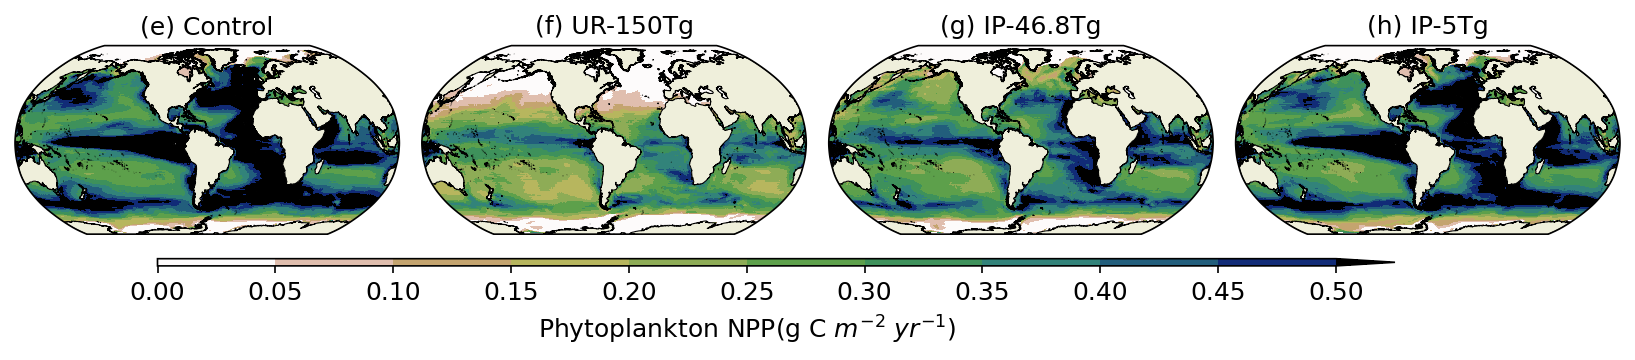

In [52]:

def get_colors(string,num,add_white = -1):
    #from pylab import *; 
    cmap = cm.get_cmap(string, num)    # PiYG
    colors=[]
    for i in range(cmap.N):
        rgb = cmap(i)[:3] # will return rgba, we take only first 3 so we get rgb
        colors.append(str(matplotlib.colors.rgb2hex(rgb))) 
    if add_white != -1:
        colors.insert(add_white,'#FFFFFF')
    return colors


mpl.rcParams['figure.dpi'] = 150
# make a da plot
# now create plot of NPP during impact winter (varying colorbars)
def get_colors(string,num,add_white = -1):
    #from pylab import *; 
    cmap = cm.get_cmap(string, num)    # PiYG
    colors=[]
    for i in range(cmap.N):
        rgb = cmap(i)[:3] # will return rgba, we take only first 3 so we get rgb
        colors.append(str(matplotlib.colors.rgb2hex(rgb))) 
    if add_white != -1:
        colors.insert(add_white,'#FFFFFF')
    return colors

FONTSIZE={}
FONTSIZE['SUPTITLE']=16
FONTSIZE['TITLE']=12
FONTSIZE['YLABEL']=12
FONTSIZE['XLABEL']=12
FONTSIZE['XTICKS']=12
FONTSIZE['CBAR_TICKS'] = 12
unit_factor = 12*1e-2*1e-3 *86400
lats = cesm_mon_ds.variables['TLAT']; lons=cesm_mon_ds.variables['TLONG']
lats_c = lats; lons_c = lons;
axes={}
pc={}
#axes['photoC_TOT_zint']=fig.add_subplot(gs[0,0],facecolor='darkgrey',projection=ccrs.Robinson(central_longitude=-60)) # this plot will be pic/poc during recovery 
boundaries={}
colors={}
cmap={}
norm={}
PFT_number={}
PFT_title={}
PFT_title['photoC_TOT_zint'] = 'All phytoplankton'
PFT_title['photoC_diat_zint']='Diatoms'
PFT_title['photoC_cocco_zint']='Coccolithophores'
PFT_title['photoC_sp_zint']='Small phytoplankton'
for PFT in ['photoC_TOT_zint','photoC_diat_zint']:
    boundaries[PFT]=np.array([0,1,2,3,4,5,6,7,8,9,10])*5e-2
    cmap_seismic = plt.cm.get_cmap('gist_earth_r',len(boundaries[PFT]))
    colors[PFT] = list(cmap_seismic(np.arange(len(boundaries[PFT]))))
    cmap[PFT] = mpl.colors.ListedColormap(colors[PFT], "")
    norm[PFT] = mpl.colors.BoundaryNorm(boundaries[PFT],ncolors=len(boundaries[PFT])-1,clip=False)


for PFT in ['photoC_cocco_zint','photoC_sp_zint']:
    boundaries[PFT]=np.array([0,1,2,3,4,5,6,7,8,9,10])*3e-2
    cmap_seismic = plt.cm.get_cmap('gist_earth_r',len(boundaries[PFT]))
    colors[PFT] = list(cmap_seismic(np.arange(len(boundaries[PFT]))))
    cmap[PFT] = mpl.colors.ListedColormap(colors[PFT], "")
    norm[PFT] = mpl.colors.BoundaryNorm(boundaries[PFT],ncolors=len(boundaries[PFT])-1,clip=False)

# MOST USER SPECIFICATIONS ARE HERE 
PFT='photoC_TOT_zint' 
PANELS = ['panel1','panel2','panel3','panel4']
panel_title={}; plot_data={}


these_cases=['nw_ur_150_tuv_01','nw_ip_46p8_tuv_ens01','nw_ip_5tg_tuv_ens01','nw_cntrl_tuv_01']




panel_title['panel1'] = '(e) Control'; case='nw_cntrl_tuv_01'; key_code='1 year mean';
plot_data['panel1'] = monthly_data[case][PFT+' '+key_code] # monthly_data[case][PFT+' '+key_code]
panel_title['panel2'] = '(f) UR-150Tg'
case='nw_ur_150_tuv_01'; plot_data['panel2'] = monthly_data[case][PFT+' '+key_code]
panel_title['panel3'] = '(g) IP-46.8Tg'
case='nw_ip_46p8_tuv_ens01'; plot_data['panel3'] = monthly_data[case][PFT+' '+key_code]
panel_title['panel4'] = '(h) IP-5Tg'
case='nw_ip_5tg_tuv_ens01'; plot_data['panel4'] = monthly_data[case][PFT+' '+key_code]

############
#
#
# Figure generation starts here 
#
#
############

land_object=cartopy.feature.NaturalEarthFeature('physical', 'land', '10m',
                                edgecolor='k',linewidth=0.5,
                                facecolor=cartopy.feature.COLORS['land'])


fig = plt.figure(figsize=(11,2.4),facecolor='white',num=1,clear=True)
gs = fig.add_gridspec(1,4) # photoC_TOT_zint
#plt.suptitle('Total column phytoplankton NPP',fontsize=FONTSIZE['SUPTITLE'])
subplot_number=0
for panel in PANELS:
    axes[panel]=fig.add_subplot(gs[0,0 + subplot_number],facecolor='white',projection=ccrs.Robinson(central_longitude=-60))
    axes[panel].set_title(panel_title[panel],fontsize=FONTSIZE['TITLE'])
    pc[panel]=axes[panel].pcolormesh(lons,lats,plot_data[panel]*unit_factor, cmap=cmap[PFT],
    norm=norm[PFT],transform=ccrs.PlateCarree())     
    axes[panel].add_feature(land_object)
    subplot_number = subplot_number+1



position = fig.add_axes([0.10,0.15,0.75,0.02]) # left,bottom,width,height
cbar1=fig.colorbar(pc[panel],cax=position,extend='max',orientation='horizontal')
cbar1.ax.tick_params(labelsize=FONTSIZE['CBAR_TICKS'])
cbar1.set_ticks(boundaries[PFT])
cbar1.set_label('Phytoplankton NPP(g C $m^{-2}$ $yr^{-1}$)',fontsize=FONTSIZE['XLABEL'])
    

plt.tight_layout()